COVIDCARE: DEMI-Based COVID-19 Screening System
This notebook:

Loads the COVIDCARE patient dataset and survey dictionary.
Identifies binary, pre-test/home-observable variables.
Builds a DEMI knowledgebase from the patient data.
Uses Laplace-smoothed 2×2 evidence weights.
Evaluates the model on a stratified hold-out set.
Provides an interactive questionnaire using Jupyter widgets.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/HI823"

DATA = os.path.join(
    BASE_PATH,
    "COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03.csv"
)

DICT = os.path.join(
    BASE_PATH,
    "COVIDCARE_survey_dictionary_v2_ForSubmission_MIT_Phase_II_2021-12-26.csv"
)

SUPPLIED_KB = os.path.join(
    BASE_PATH,
    "COVIDCARE_DEMI_knowledgebase_v4.csv"
)

TARGET = "PCR Test Positive"
ALPHA = 1.0

for f in [DATA, DICT, SUPPLIED_KB]:

    if not os.path.exists(f):

        raise FileNotFoundError(
            f"\nMissing file:\n{f}\n\n"
            f"Make sure the CSV file is located in:\n{BASE_PATH}"
        )
# Load data

df = pd.read_csv(DATA)

survey_dict = pd.read_csv(DICT)

supplied_kb = pd.read_csv(SUPPLIED_KB)

# Display information

print("Patient data shape:", df.shape)

print("Survey dictionary shape:", survey_dict.shape)

print("Supplied knowledge base shape:", supplied_kb.shape)

print("\nTarget distribution:")

print(
    df[TARGET].value_counts(dropna=False)
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Patient data shape: (822, 472)
Survey dictionary shape: (472, 10)
Supplied knowledge base shape: (70983, 11)

Target distribution:
PCR Test Positive
0.0    501
NaN    263
1.0     58
Name: count, dtype: int64


In [4]:
# Clean the target
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

print(f"Usable patients: {len(df):,}")
print(f"PCR-positive: {df[TARGET].sum():,}")
print(f"PCR-negative: {(df[TARGET] == 0).sum():,}")

Usable patients: 559
PCR-positive: 58
PCR-negative: 501


1. Identify home-observable / pre-test variables


The supplied COVIDCARE data use coded variable prefixes. We restrict the initial model to binary variables from symptom/risk-factor/travel/vaccination sections rather than variables that could contain the PCR result itself.

For a formal publication, the exact variable-inclusion protocol should be fixed before model training and documented from the survey instrument.

In [5]:
HOME_PREFIXES = (
    "30103-",  # conditions / risk factors
    "30150-",  # symptoms
    "30153-",  # symptoms
    "30154-",  # respiratory symptoms
    "30183-",  # travel
    "30184-",  # travel
    "36096-",  # vaccination
)

candidate_cols = [
    c for c in df.columns
    if c.startswith(HOME_PREFIXES) and c != TARGET
]

features = []
for c in candidate_cols:
    x = pd.to_numeric(df[c], errors="coerce")
    vals = set(x.dropna().unique())
    if vals and vals.issubset({0, 1}) and x.notna().sum() >= 30:
        features.append(c)

print("Candidate binary home/pre-test features:", len(features))


Candidate binary home/pre-test features: 75


In [6]:
# Helper for readable question labels
def question_for(col):
    # Try common dictionary column names without assuming one exact schema.
    name_col = next(
        (c for c in ["Variable Name", "variable", "Variable", "Name"]
         if c in survey_dict.columns),
        None
    )
    if name_col is None:
        return col

    hit = survey_dict[survey_dict[name_col].astype(str) == str(col)]
    if hit.empty:
        return col

    row = hit.iloc[0]
    for c in ["Prompt", "Question", "Description", "Label"]:
        if c in survey_dict.columns and pd.notna(row[c]) and str(row[c]).strip():
            return str(row[c]).replace("\n", " ")

    return col

pd.DataFrame({
    "variable": features[:10],
    "question": [question_for(c) for c in features[:10]]
})


,variable,question
0,30103-conditionsrisks-14,Do you have any of the following underlying co...
1,30103-conditionsrisks-2,Do you have any of the following underlying co...
2,30103-conditionsrisks-3,Do you have any of the following underlying co...
3,30103-conditionsrisks-4,Do you have any of the following underlying co...
4,30103-conditionsrisks-5,Do you have any of the following underlying co...
5,30103-conditionsrisks-22,Do you have any of the following underlying co...
6,30103-conditionsrisks-23,Do you have any of the following underlying co...
7,30103-conditionsrisks-6,Do you have any of the following underlying co...
8,30103-conditionsrisks-7,Do you have any of the following underlying co...
9,30103-conditionsrisks-15,Do you have any of the following underlying co...


2. Build the DEMI knowledgebase

For every binary feature (X), construct a 2×2 table against the PCR target:

[ DEMI(X)=\log_2\left(\frac{P(X=1|COVID+) }{P(X=1|COVID-)}\right) ]

Laplace smoothing (α=1) prevents zero probabilities.

Positive values indicate evidence toward COVID-19; negative values indicate evidence away from COVID-19.

In [8]:
def build_demi_kb(data, feature_cols, alpha=1.0):
    y = data[TARGET].to_numpy(dtype=int)
    rows = []

    for col in feature_cols:
        x = pd.to_numeric(data[col], errors="coerce").fillna(0).to_numpy(dtype=int)

        a = int(((x == 1) & (y == 1)).sum())
        b = int(((x == 1) & (y == 0)).sum())
        c = int(((x == 0) & (y == 1)).sum())
        d = int(((x == 0) & (y == 0)).sum())

        p_x_y1 = (a + alpha) / (a + c + 2 * alpha)
        p_x_y0 = (b + alpha) / (b + d + 2 * alpha)

        rows.append({
            "feature": col,
            "n_code_target": a,
            "n_code_no_target": b,
            "n_target_no_code": c,
            "n_no_code_no_target": d,
            "p_feature_given_positive": p_x_y1,
            "p_feature_given_negative": p_x_y0,
            "demi_weight": np.log2(p_x_y1 / p_x_y0),
        })

    out = pd.DataFrame(rows)
    out["question"] = out["feature"].map(question_for)
    return out

kb = build_demi_kb(df, features, ALPHA)

print("Knowledgebase rows:", len(kb))
kb.head()


Knowledgebase rows: 75


,feature,n_code_target,n_code_no_target,n_target_no_code,n_no_code_no_target,p_feature_given_positive,p_feature_given_negative,demi_weight,question
0,30103-conditionsrisks-14,11,62,47,439,0.200000,0.125249,0.675207,Do you have any of the following underlying co...
1,30103-conditionsrisks-2,7,18,51,483,0.133333,0.037773,1.819596,Do you have any of the following underlying co...
2,30103-conditionsrisks-3,10,60,48,441,0.183333,0.121272,0.596218,Do you have any of the following underlying co...
3,30103-conditionsrisks-4,13,76,45,425,0.233333,0.153082,0.608092,Do you have any of the following underlying co...
4,30103-conditionsrisks-5,3,10,55,491,0.066667,0.021869,1.608092,Do you have any of the following underlying co...


In [9]:
# Rank evidence
top_positive = kb.sort_values("demi_weight", ascending=False).head(15)
top_negative = kb.sort_values("demi_weight", ascending=True).head(15)

print("Strongest positive evidence:")
display(top_positive[["feature", "question", "demi_weight"]])

print("\nStrongest negative evidence:")
display(top_negative[["feature", "question", "demi_weight"]])

Strongest positive evidence:


,feature,question,demi_weight
9,30103-conditionsrisks-15,Do you have any of the following underlying co...,4.067524
7,30103-conditionsrisks-6,Do you have any of the following underlying co...,4.067524
32,30150-flu_tst_symptoms-23,Which of the following symptoms did you experi...,4.067524
33,30150-flu_tst_symptoms-30,Which of the following symptoms did you experi...,4.067524
5,30103-conditionsrisks-22,Do you have any of the following underlying co...,3.389452
39,30153-Symptoms-6,"In the last 14 days, did you experience any of...",3.308532
8,30103-conditionsrisks-7,Do you have any of the following underlying co...,3.067524
24,30150-flu_tst_symptoms-8,Which of the following symptoms did you experi...,3.067524
30,30150-flu_tst_symptoms-16,Which of the following symptoms did you experi...,3.067524
26,30150-flu_tst_symptoms-10,Which of the following symptoms did you experi...,3.067524



Strongest negative evidence:


,feature,question,demi_weight
41,30154-Symptoms_Resp-1,"In the last 14 days, did you experience any of...",-1.853722
34,30153-Symptoms-1,"In the last 14 days, did you experience any of...",-1.600855
15,30103-conditionsrisks-13,Do you have any of the following underlying co...,-1.487065
17,30103-conditionsrisks-20,Do you have any of the following underlying co...,-1.008579
63,30183-states_specify-28,Please specify which states you traveled to (o...,-0.976870
13,30103-conditionsrisks-10,Do you have any of the following underlying co...,-0.391908
37,30153-Symptoms-4,"In the last 14 days, did you experience any of...",0.067524
16,30103-conditionsrisks-19,Do you have any of the following underlying co...,0.193055
54,30183-states_specify-11,Please specify which states you traveled to (o...,0.260169
52,30183-states_specify-9,Please specify which states you traveled to (o...,0.482561


In [10]:
# SAVE GENERATED DEMI KNOWLEDGEBASE
# Save the newly generated DEMI knowledgebase
GENERATED_KB = os.path.join(
    BASE_PATH,
    "COVIDCARE_DEMI_knowledgebase_generated.csv"
)
kb.to_csv(GENERATED_KB, index=False)
print("Saved:", GENERATED_KB)

# Inspect supplied knowledgebase

if os.path.exists(SUPPLIED_KB):

    supplied = pd.read_csv(SUPPLIED_KB)

    print(
        "Supplied DEMI knowledgebase shape:",
        supplied.shape
    )

    display(supplied.head())

else:

    print(
        "Supplied DEMI knowledgebase file was not found at:",
        SUPPLIED_KB
    )

Saved: /content/drive/MyDrive/HI823/COVIDCARE_DEMI_knowledgebase_generated.csv
Supplied DEMI knowledgebase shape: (70983, 11)


,row_order,requested_concept_code,target_concept_code,concept_code,standard_concept_name,n_code_target,n_code_no_target,n_target_no_code,n_no_code_no_target,n_target_before_code,n_code_before_target
0,1,30082-Race-2,30082-Race-2,30082-Race-1,Race selected; White,20,385,333,45,333,385
1,2,30082-Race-3,30082-Race-3,30082-Race-1,Race selected; White,3,402,27,351,27,402
2,3,30082-Race-4,30082-Race-4,30082-Race-1,Race selected; White,7,398,6,372,6,398
3,4,30082-Race-5,30082-Race-5,30082-Race-1,Race selected; White,0,405,2,376,2,405
4,5,30082-Race-6,30082-Race-6,30082-Race-1,Race selected; White,2,403,11,367,11,403


3. Train/test evaluation

The DEMI weights are learned only from the training partition and then applied to the held-out partition. This avoids evaluating the model on the same patients used to calculate the evidence weights.

In [11]:
train, test = train_test_split(
    df,
    test_size=0.25,
    stratify=df[TARGET],
    random_state=42
)

def train_demi(data, feature_cols, alpha=1.0):
    model = build_demi_kb(data, feature_cols, alpha).set_index("feature")
    prevalence = data[TARGET].mean()

    # Smoothed population prior log-odds
    prior = np.log(
        (prevalence + alpha) /
        (1 - prevalence + alpha)
    )
    return model, prior

def demi_predict(model, prior_log_odds, data):
    score = np.full(len(data), prior_log_odds, dtype=float)

    for feature, row in model.iterrows():
        if feature not in data:
            continue

        x = pd.to_numeric(data[feature], errors="coerce").fillna(0).to_numpy()
        score += np.where(x == 1, row["demi_weight"], 0.0)

    score = np.clip(score, -30, 30)
    return 1.0 / (1.0 + np.exp(-score))

model, prior = train_demi(train, features, ALPHA)
test_prob = demi_predict(model, prior, test)
test_pred = (test_prob >= 0.50).astype(int)

auc = roc_auc_score(test[TARGET], test_prob)
accuracy = accuracy_score(test[TARGET], test_pred)

print(f"Training patients: {len(train):,}")
print(f"Testing patients:  {len(test):,}")
print(f"ROC-AUC:           {auc:.3f}")
print(f"Accuracy @ 0.50:   {accuracy:.3f}")
print("\nClassification report:")
print(classification_report(test[TARGET], test_pred, digits=3))
print("\nConfusion matrix:")
print(confusion_matrix(test[TARGET], test_pred))


Training patients: 419
Testing patients:  140
ROC-AUC:           0.824
Accuracy @ 0.50:   0.686

Classification report:
              precision    recall  f1-score   support

           0      0.966     0.672     0.792       125
           1      0.226     0.800     0.353        15

    accuracy                          0.686       140
   macro avg      0.596     0.736     0.573       140
weighted avg      0.886     0.686     0.745       140


Confusion matrix:
[[84 41]
 [ 3 12]]


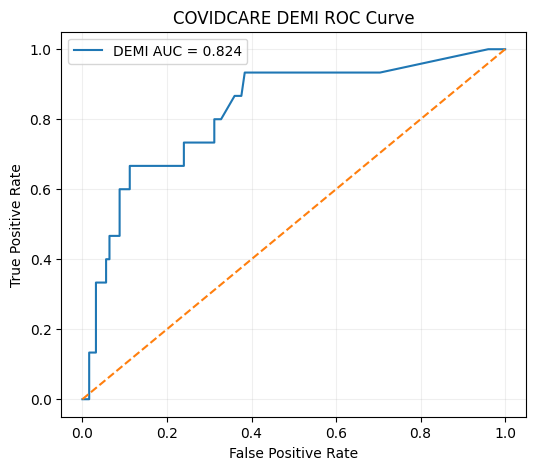

In [12]:
# ROC curve
fpr, tpr, _ = roc_curve(test[TARGET], test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"DEMI AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("COVIDCARE DEMI ROC Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [13]:
# ============================================================
#  INTERACTIVE AI SCREENING QUESTIONNAIRE
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

# Use the 15 strongest DEMI evidence features
interactive_kb = (
    model.reset_index()
         .assign(abs_weight=lambda x: x["demi_weight"].abs())
         .sort_values("abs_weight", ascending=False)
         .head(15)
         .copy()
)

controls = []

for _, row in interactive_kb.iterrows():

    feature = row["feature"]
    weight = float(row["demi_weight"])
    question = row["question"]

    widget = widgets.ToggleButtons(
        options=[
            ("Unknown", None),
            ("No", 0),
            ("Yes", 1)
        ],
        value=None,
        description="",
        layout=widgets.Layout(width="230px")
    )

    box = widgets.VBox([
        widgets.HTML(
            value=f"<b>{question}</b>"
        ),
        widget
    ])

    controls.append(
        (feature, weight, widget, box)
    )


# ------------------------------------------------------------
# Calculate button
# ------------------------------------------------------------

calculate = widgets.Button(
    description="Calculate DEMI Screening Risk",
    button_style="primary",
    icon="calculator",
    layout=widgets.Layout(width="280px")
)

output = widgets.Output(
    layout=widgets.Layout(
        border="1px solid #cccccc",
        padding="10px",
        width="700px"
    )
)


# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------

def calculate_risk(_):

    with output:

        clear_output(wait=True)

        # Start with population prior
        score = float(prior)

        evidence = []

        # Add DEMI weights for "Yes" responses
        for feature, weight, widget, _ in controls:

            if widget.value == 1:

                score += weight

                evidence.append(
                    (feature, weight)
                )

        # Prevent numerical overflow
        score = float(
            np.clip(score, -30, 30)
        )

        # Logistic transformation
        probability = 1 / (
            1 + np.exp(-score)
        )

        print(
            f"Estimated COVID-19 screening probability: "
            f"{probability:.1%}"
        )

        print("\n")


        # ----------------------------------------------------
        # Risk category
        # ----------------------------------------------------

        if probability >= 0.70:

            print("HIGHER ESTIMATED RISK")

            print(
                "Consider prompt COVID-19 testing and "
                "clinical evaluation, especially if symptoms "
                "are worsening."
            )

        elif probability >= 0.30:

            print("INTERMEDIATE ESTIMATED RISK")

            print(
                "Consider COVID-19 testing and monitoring."
            )

        else:

            print("LOWER ESTIMATED RISK")

            print(
                "A low score does not rule out COVID-19."
            )


        # ----------------------------------------------------
        # Evidence
        # ----------------------------------------------------

        print("\nEvidence contributed by:")

        if evidence:

            for feature, weight in sorted(
                evidence,
                key=lambda x: abs(x[1]),
                reverse=True
            ):

                # Find question text
                question = interactive_kb.loc[
                    interactive_kb["feature"] == feature,
                    "question"
                ].iloc[0]

                print(
                    f"  {question} | "
                    f"DEMI weight = {weight:+.3f}"
                )

        else:

            print(
                "  No positive evidence selected; "
                "result is primarily based on the population prior."
            )


# Connect button to prediction
calculate.on_click(calculate_risk)


# ------------------------------------------------------------
# Display interface
# ------------------------------------------------------------

interface = widgets.VBox(
    [box for _, _, _, box in controls]
    + [calculate, output],
    layout=widgets.Layout(
        width="750px"
    )
)

display(interface)

In [14]:
final_kb = kb[
    [
        "feature",
        "question",
        "n_code_target",
        "n_code_no_target",
        "n_target_no_code",
        "n_no_code_no_target",
        "p_feature_given_positive",
        "p_feature_given_negative",
        "demi_weight",
    ]
].sort_values(
    "demi_weight",
    ascending=False
)

FINAL_KB = os.path.join(
    BASE_PATH,
    "COVIDCARE_DEMI_knowledgebase_final.csv"
)

final_kb.to_csv(
    FINAL_KB,
    index=False
)

print("Created:", FINAL_KB)

display(
    final_kb.head(20)
)

Created: /content/drive/MyDrive/HI823/COVIDCARE_DEMI_knowledgebase_final.csv


,feature,question,n_code_target,n_code_no_target,n_target_no_code,n_no_code_no_target,p_feature_given_positive,p_feature_given_negative,demi_weight
9,30103-conditionsrisks-15,Do you have any of the following underlying co...,1,0,57,501,0.033333,0.001988,4.067524
7,30103-conditionsrisks-6,Do you have any of the following underlying co...,1,0,57,501,0.033333,0.001988,4.067524
32,30150-flu_tst_symptoms-23,Which of the following symptoms did you experi...,1,0,57,501,0.033333,0.001988,4.067524
33,30150-flu_tst_symptoms-30,Which of the following symptoms did you experi...,1,0,57,501,0.033333,0.001988,4.067524
5,30103-conditionsrisks-22,Do you have any of the following underlying co...,4,3,54,498,0.083333,0.007952,3.389452
39,30153-Symptoms-6,"In the last 14 days, did you experience any of...",25,21,33,480,0.433333,0.043738,3.308532
8,30103-conditionsrisks-7,Do you have any of the following underlying co...,1,1,57,500,0.033333,0.003976,3.067524
24,30150-flu_tst_symptoms-8,Which of the following symptoms did you experi...,1,1,57,500,0.033333,0.003976,3.067524
30,30150-flu_tst_symptoms-16,Which of the following symptoms did you experi...,0,0,58,501,0.016667,0.001988,3.067524
26,30150-flu_tst_symptoms-10,Which of the following symptoms did you experi...,1,1,57,500,0.033333,0.003976,3.067524
